# Homework 3: Bayesian Models and Monte Carlo

BEE 4850/5850, Spring 2025

**Name**:

**ID**:

> **Due Date**
>
> Friday, 3/14/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to quantify uncertainties for a simple model
    using Bayesian statistics and rejection sampling.
-   Problem 2 asks you to use Monte Carlo simulation to calculate annual
    expected flooding damages.
-   Problem 3 (only required for students in BEE 5850) asks you to
    conduct cost-benefit analyses of housing elevation levels under
    future flooding uncertainty using Monte Carlo simulations.

### Load Environment

**USED CHATGPT (OpenAI, 2025):** converted Julia to Python for start of script

In [161]:
import random  # random number generation and seed-setting
import pandas as pd  # tabular data structure
import csv  # reads/writes .csv files (though pandas is usually used for this)
import numpy as np  # numerical computing
import scipy.stats as stats  # interface to work with probability distributions
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns  # additional statistical plotting tools
import statistics  # statistical quantities like mean, median, etc.
from scipy.optimize import minimize  # optimization tools
random.seed(44)


## Problems

### Scoring

-   Problem 1 is worth 13 points.
-   Problem 2 is worth 7 points.
-   Problem 3 is worth 5 points.

### Problem 1

Consider the class-cheating testing procedure from [Homework
1](https://viveks.me/simulation-data-analysis/hw/hw01.html). As a
reminder, the procedure is as follows:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

Suppose that, after conducting the procedure on your class of 100
students, you get 40 “Yes, I cheated” responses. You are skeptical that
your class is broadly engaged in cheating and have a prior belief that
the probability of cheating $\theta$ is unlikely to be high. We’ll
express this prior using a beta distribution, \$(3, 40), which is shown
below. You would like to understand the range of cheating propensity
which is consistent with your prior beliefs and the outcomes from the
detection procedure.

**In this problem**:

-   A) Construct a Bayesian probability model (based on the data-generating
    process from Homework 1 and our prior on the cheating probability)
    for the “Yes, I cheated” counts. You can compute the likelihood
    based on the combination of the fair coin flip and the “true”
    cheating probability $\theta$.
-   B) Plot the posterior $p(\theta | y)$ using a grid approximation
    (looping over values of $\theta$).
-   C) Use rejection sampling to draw 1,000 samples from the posterior and
    plot the distribution of samples. How well are you capturing the
    posterior you obtained from the grid approximation? Would you prefer
    to have more samples?
-   D) Report the expected value of $\theta$ and its 90% credible interval.
    What conclusions can you draw about cheating probability and whether
    your belief in your class was warranted? How much uncertainty exists
    as a result of this privacy-protecting procedure?
-   E) Repeat the analysis with a less constrained prior of your choosing.
    How does that change your inferences and conclusions? What does this
    tell you about the effectiveness of the procedure?



A) Construct a Bayesian probability model (based on the data-generating
    process from Homework 1 and our prior on the cheating probability)
    for the “Yes, I cheated” counts. You can compute the likelihood
    based on the combination of the fair coin flip and the “true”
    cheating probability $\theta$.

Recall from hw 1: Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

Outcomes:
H --> answer honest --> the number here that say "I did cheat" would be p_fair * p_cheat = 1/2*p_cheat
T --> flip agian, and IF it comes up heads, say "i did cheat" so this would be p_fair * p_fair = 1/4
So the associated probability in one single binomial distributiont that represents this, would be 1/2*p_cheat + 1/4


Likelihood of a given theta, given that 40/100 said "yes i cheated", and we know the data generating set up (i.e., probability of saying "yes i cheated" because the coin flip TOLD you to, PLUS the probabilty of saying "yes i cheated" because the coin flip said you had to be honest, and there is a "true" probability of cheating that we can recover from this.

In [162]:
# likelihood: Likelihood of a given theta, given that 40/100 said "yes i cheated", 
# and we know the data generating set up (i.e., probability of saying "yes i cheated" 
# because the coin flip TOLD you to, PLUS the probabilty of saying "yes i cheated" because the coin 
# flip said you had to be honest, and there is a "true" probability of cheating that we can recover from this.
theta = np.linspace(0,1,100)

def find_likelihood(theta_):
    likelihood_ = stats.binom.pmf(k = 40, n = 100, p = (0.25+.5*theta_), loc=0)
    return likelihood_

likelihood = []
for i in np.arange(0, len(theta)):
    likelihood.append(find_likelihood(theta[i]))
val_max = np.max(likelihood)
idx_max = np.argmax(likelihood)
print(f'Max prob cheating {round(val_max,3)} (likelihood) at index {idx_max}')

Max prob cheating 0.081 (likelihood) at index 30


In [163]:
def find_prior(theta_):
    # x, a, b, loc=0, scale=1
    prior_ = stats.beta.pdf(theta_, a = 3, b = 40, loc=0, scale=1)
    return prior_

# num_yes_cheat = np.arange(1, 101)
beta_prior = []
for i in np.arange(0, len(theta)):
    prior_ = find_prior(theta[i])
    beta_prior.append(prior_)

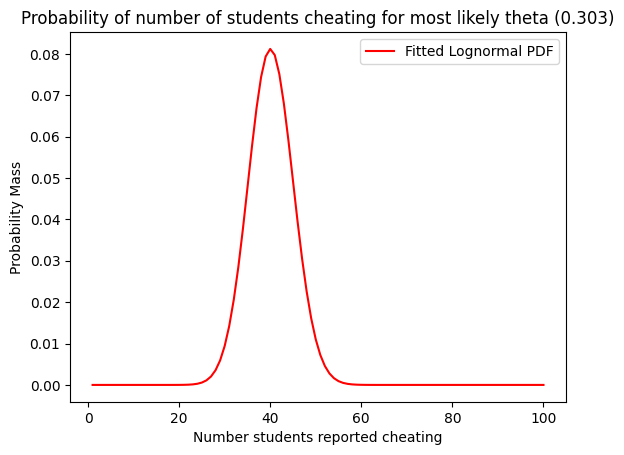

In [164]:
# get pdf and plot
x = np.arange(1, 101)
pdf_binom = stats.binom.pmf(k=x, n=100, p=(0.25+0.5*theta[idx_max]), loc=0)
plt.plot(x, pdf_binom, 'r-', label='Fitted Lognormal PDF')
plt.xlabel('Number students reported cheating')
plt.ylabel('Probability Mass')
plt.title(f'Probability of number of students cheating for most likely theta ({np.round(theta[idx_max],3)})')
plt.legend()
plt.show()

^ The plot above just confirms that the most likely theta found, does in fact result in a binomial distribtuion that has 40/100 students saying yes as being likely.

In [165]:
df = pd.DataFrame({
    'theta': theta,
    'likelihood': likelihood,
    'beta_prior': beta_prior
})

df['posterior'] = df['likelihood']*df['beta_prior'] 



df['log_likelihood'] = np.log(df['likelihood'])
df['log_beta_prior'] = np.log(df['beta_prior'])

df['log_posterior'] = df['log_likelihood']+df['log_beta_prior']

df['log_posterior_transform'] = np.exp(df['log_posterior'])


/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [166]:
val_max = np.max(df['posterior'])
idx_max = np.argmax(df['posterior'])
print(f'Max prob cheating posterior {val_max} at index {idx_max}')

val_max = np.max(df['log_posterior'])
idx_max = np.argmax(df['log_posterior'])
print(f'Max prob cheating log-posterior {val_max} at index {idx_max}, exponential transform: {np.exp(val_max)}')
#print(np.exp(val_max))

Max prob cheating posterior 0.04803526241944725 at index 10
Max prob cheating log-posterior -3.0358199040470426 at index 10, exponential transform: 0.04803526241944722


B) Plot the posterior $p(\theta | y)$ using a grid approximation (looping over values of $\theta$)

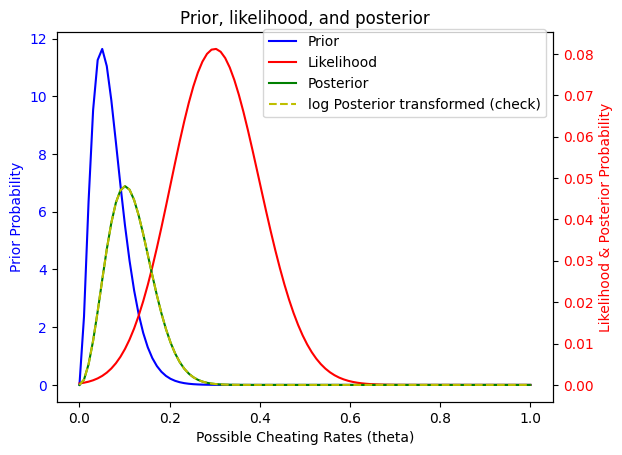

In [167]:
fig, ax1 = plt.subplots()

# Primary y-axis (Prior)
ax1.plot(df['theta'], df['beta_prior'], 'b-', label='Prior')
ax1.set_xlabel('Possible Cheating Rates (theta)')
ax1.set_ylabel('Prior Probability', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Secondary y-axis (Likelihood & Posterior)
ax2 = ax1.twinx()
ax2.plot(df['theta'], df['likelihood'], 'r-', label='Likelihood')
ax2.plot(df['theta'], df['posterior'], 'g-', label='Posterior')
ax2.plot(df['theta'], np.exp(df['log_posterior']), 'y--', label='log Posterior transformed (check)')
ax2.set_ylabel('Likelihood & Posterior Probability', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Title and Legend
plt.title('Prior, likelihood, and posterior')
fig.legend(loc='upper right', bbox_to_anchor=(.9,.9))

plt.show()


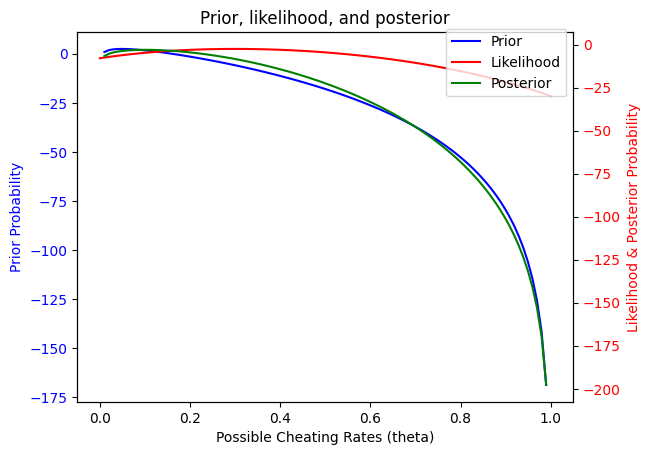

In [168]:
fig, ax1 = plt.subplots()

# Primary y-axis (Prior)
ax1.plot(df['theta'], df['log_beta_prior'], 'b-', label='Prior')
ax1.set_xlabel('Possible Cheating Rates (theta)')
ax1.set_ylabel('Prior Probability', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Secondary y-axis (Likelihood & Posterior)
ax2 = ax1.twinx()
ax2.plot(df['theta'], df['log_likelihood'], 'r-', label='Likelihood')
ax2.plot(df['theta'], df['log_posterior'], 'g-', label='Posterior')
ax2.set_ylabel('Likelihood & Posterior Probability', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Title and Legend
plt.title('Prior, likelihood, and posterior')
fig.legend(loc='upper right', bbox_to_anchor=(.9,.9))

plt.show()


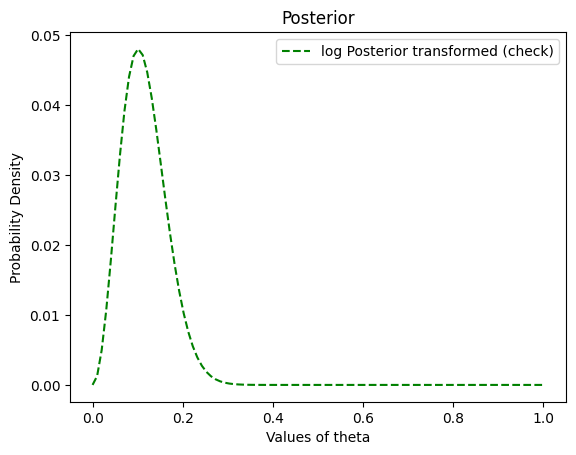

In [169]:
plt.plot(df['theta'], np.exp(df['log_posterior']), 'g--', label='log Posterior transformed (check)')
plt.xlabel('Values of theta')
plt.ylabel('Probability Density')
plt.title(f'Posterior')
plt.legend()
plt.show()

For the following rejection sampling, my approach was: my proposal distribution was just essentially a rectangle composed of two uniform distributions: one which samples the cheating rate from 0 to 1, and the other which samples the probability density from 0 to 0.05 (which is higher than the highest point on my posterior distribution). My target distribution is just my posterior, which - for each theta chosen from the first uniform distribution, I can then calculate the associated density by 1) finding the likelihood associated with 40/100 for a binomial with the correct coresponding probability (0.25*0.5*theta) and multiplying that by the prior for that theta (to get the posterior associated with that theta), and then 2) seeing if the probability density sampled from my second distribution is above or below that calculated likelihood; if it's below, then the sample is kept, if it's above, then the sample is rejected.

C) Use rejection sampling to draw 1,000 samples from the posterior and
    plot the distribution of samples. How well are you capturing the
    posterior you obtained from the grid approximation? Would you prefer
    to have more samples?

In [170]:
# Rejection sampling
nsamp = 1_000
unif_theta = np.random.uniform(0, 1, nsamp)
unif_density = np.random.uniform(0, 0.07, nsamp)

keep_samp = []
for i in np.arange(0, len(unif_theta)):
    likelihood_ = find_likelihood(unif_theta[i])
    #print('likelihood_', likelihood_)
    prior_ = find_prior(unif_theta[i])
    #print('prior_', prior_)
    posterior_ = np.exp(np.log(likelihood_)+np.log(prior_))
    #print('posterior_',posterior_)
    # check if posterior is above or below the density sampled from the second unif dist; if below - keep:
    #print(unif_density[i])
    if unif_density[i]< posterior_:
        #print('keep sample')
        keep_samp.append(unif_theta[i])
print(f'The number of samples kept out of {nsamp}, is {len(keep_samp)}')

The number of samples kept out of 1000, is 73


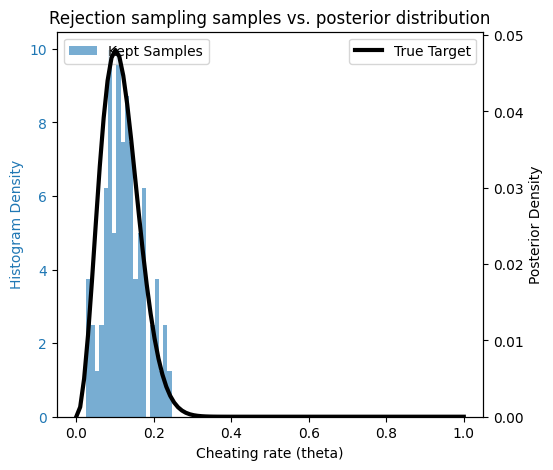

In [190]:
fig, ax1 = plt.subplots(figsize=(5.5, 5))

# Plot histogram on primary y-axis
ax1.hist(keep_samp, bins=20, density=True, alpha=0.6, label='Kept Samples', color='C0')
ax1.set_xlabel("Cheating rate (theta)")
ax1.set_ylabel("Histogram Density", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# Create a second y-axis
ax2 = ax1.twinx()
ax2.plot(df['theta'], df['posterior'], linewidth=3, color='black', label='True Target')
ax2.set_ylabel("Posterior Density", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0)

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Rejection sampling samples vs. posterior distribution')

plt.show()


**Commentary:** How well are you capturing the posterior you obtained from the grid approximation? Would you prefer to have more samples?

This rejection sampling approach captures the posterior from the grid approximation surprisingly well, even though only about a tenth of the samples were kept (roughly 100 of the 1,000 samples). I would prefer more (just because the more I have, the more I would trust the estimate and the credible intervals), however I feel like overall this approach has captured the posterior reasonably well and since I'm not particularly concerned about the tail behavior, it is likely sufficient.

D) Report the expected value of $\theta$ and its 90% credible interval. What conclusions can you draw about cheating probability and whether your belief in your class was warranted? How much uncertainty exists as a result of this privacy-protecting procedure?

In [172]:
theta_expecteed = np.mean(keep_samp)
theta_05, theta_95 = np.quantile(keep_samp, [0.05, 0.95])
print(f'The expected theta is {round(theta_expecteed,2)} and the 90% credible interval is {round(theta_05, 2)} to {round(theta_95,2)}.')

The expected theta is 0.12 and the 90% credible interval is 0.04 to 0.21.


**COMMENTARY - What conclusions can you draw about cheating probability and whether your belief in your class was warranted? How much uncertainty exists as a result of this privacy-protecting procedure?:** Based on the analyis above, the expected probability of cheating is 11% and the 90% credible interval is 3 to 19%. As stated in the question framing, our prior belief is that the class is not broadly engaged in cheating, and as such we used a relatively tightly constrained prior. I think that to some extent, this relativley heavily dictated the shape of the posterior (as can be seen by the way the prior "pulls" the posterior to the left, compared to the likelihood). Based only on these results, I would conclude that cheating is not particularly prevelant (I wouldn't consider 11% particularly high, and the 90% credible interval is below 20%, though I suppose that the definition of "prevalent cheating" it's relativley subjective.) That being said, the uncertainty as a result of this privacy protecting procedure is still high, resulting in a relatively wide 90% credible interval.

E) Repeat the analysis with a less constrained prior of your choosing. How does that change your inferences and conclusions? What does this tell you about the effectiveness of the procedure?


### Problem 2

You have been asked by a client to assess the risks of flooding to their
home (which is valued at \$400,000 and only floods when the stream water
levels exceed 1.5m). They would like to know the probability
distribution of annual flood damages to their home if they do not take
any preventative floodproofing measures. After some hydrologic analysis,
you have developed a 40-year record of annual maximum water levels (in
m) at the nearby stream.

You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.

**In this problem**:

-   Fit a log-normal distribution to the water depth data by maximizing
    likelihood.
-   Use 10,000 samples from this distribution to estimate the expected
    damages from an annual maximum flood event using Monte Carlo
    simulation. Report your estimate as well as its standard error.
    Would you want to use more samples? Why or why not?



**USED CHATGPT (OpenAI, 2025):** converted Julia to Python to convert course notes code on rejection sampling to python; any additional changes reflect my own work. Also used chatgpt to troubleshoot an error I was getting when I tried to multiply damage fractions by 400,000, turns out you can't multiply a list of values by a number haha so chatgpt told me to convert to numpy array first which fixed the problem i was having.

MLE outputs of lognormal dist: shape 0.24963728245631378, loc 0, scale 1.1509354338959927


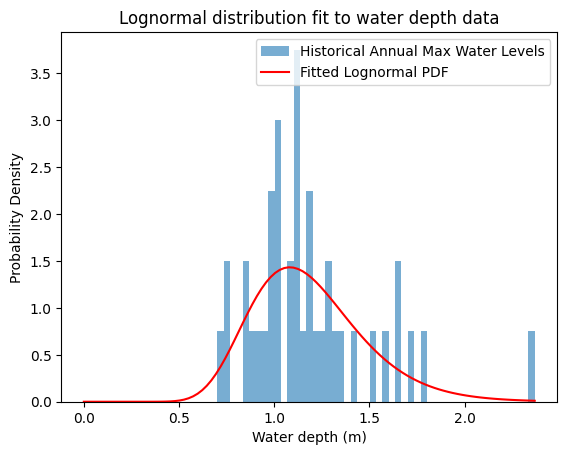

In [173]:
# read in data:
water = pd.read_csv("data/water_depths.csv") 
# print(water.head())

# log-normal distribution to the water depth data by maximizing likelihood:
shape, loc, scale = stats.lognorm.fit(water['depths'], floc= 0)
print(f'MLE outputs of lognormal dist: shape {shape}, loc {loc}, scale {scale}')



# get pdf and plot
x = np.linspace(0, max(water['depths']), 100) #min(water['depths'])
# pdf(x, s, loc=0, scale=1)
pdf = stats.lognorm.pdf(x, shape, loc, scale)
plt.hist(water, bins=50, density=True, alpha=0.6, label='Historical Annual Max Water Levels')
plt.plot(x, pdf, 'r-', label='Fitted Lognormal PDF')
plt.xlabel('Water depth (m)')
plt.ylabel('Probability Density')
plt.title('Lognormal distribution fit to water depth data')
plt.legend()
plt.show()

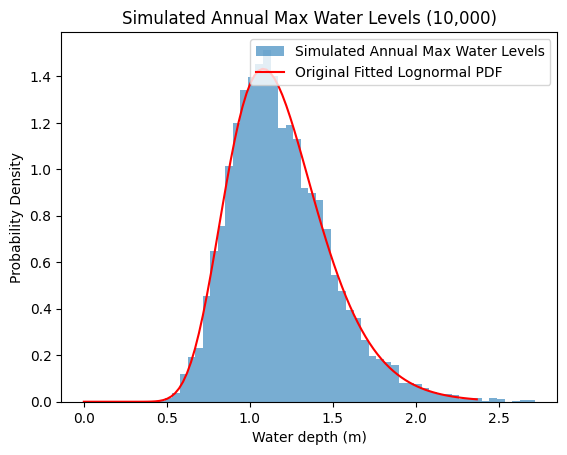

In [174]:
# 10,000 samples from distribution
# take 10,000 random samples from this lognormal pdf,
samples = stats.lognorm.rvs(s = shape, loc=loc, scale=scale, size=10000, random_state=None)

# plot samples for reference:
plt.hist(samples, bins=50, density=True, alpha=0.6, label='Simulated Annual Max Water Levels')
plt.plot(x, pdf, 'r-', label='Original Fitted Lognormal PDF')
plt.xlabel('Water depth (m)')
plt.ylabel('Probability Density')
plt.title('Simulated Annual Max Water Levels (10,000)')
plt.legend()
plt.show()



You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.

**NOTE ABOUT TACTIC:** In the problem framing, the house only floods when the height of the water is 1.5m or higher. As such, I first calculated h from the water depth above (i.e., water depth from simulation - 1.5), and then proceeded to use the equation where damage occurs only if h>0, i.e., if water depth is > 1.5. In this framing, the x in in the equation is also h (i.e., depth of water in home). Additionally, we know the original value of the house is $400,000, which we can use to translate fraction of value damaged into an actual dollar amount.

In [175]:
# estimate the expected damages from an annual maximum flood event using Monte Carlo simulation
# i.e., plug in water level sample estimate to the equation above
h = samples-1.5
num_exceed_thresh = (h>0).sum()

k = 1.25
x_0 = 2
damages = []
for i in range(0,len(h)):
    if h[i] > 0:
        damage = (1/(1+np.exp(-k*(h[i]-x_0))))
        damages.append(damage)
damages = np.array(damages) 
damages_dollars = (damages*400000)

In [176]:
print(f'The number of simulated events exceeding the 1.5 threshold is: {num_exceed_thresh}, and confirming that damages were calculated for: {len(damages)}.')

The number of simulated events exceeding the 1.5 threshold is: 1419, and confirming that damages were calculated for: 1419.


Use 10,000 samples from this distribution to estimate the expected
    damages from an annual maximum flood event using Monte Carlo
    simulation. Report your estimate as well as its standard error.
    Would you want to use more samples? Why or why not?


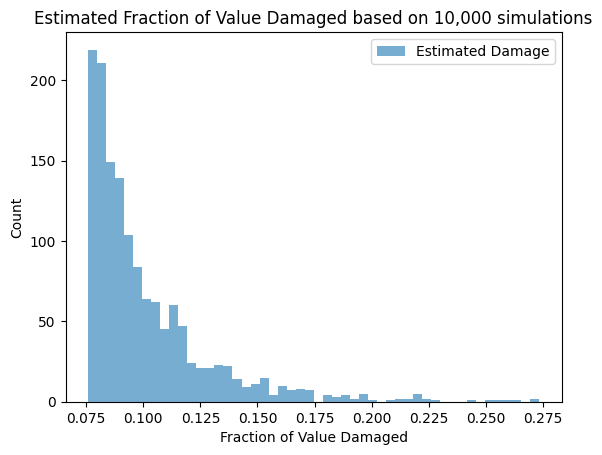

In [177]:
plt.hist(damages, bins=50, density=False, alpha=0.6, label='Estimated Damage')
plt.xlabel('Fraction of Value Damaged')
plt.ylabel('Count')
plt.title('Estimated Fraction of Value Damaged based on 10,000 simulations')
plt.legend()
plt.show()

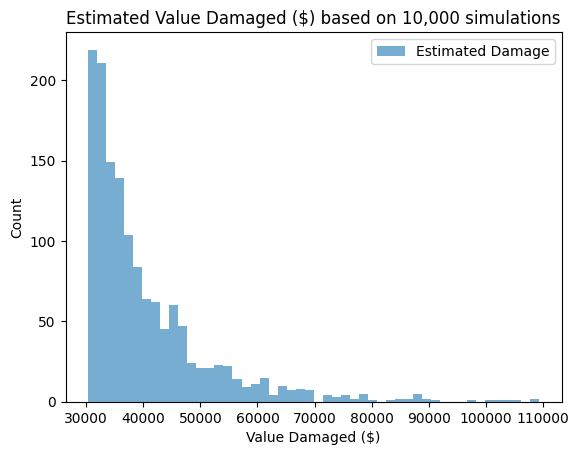

In [178]:
plt.hist(damages_dollars, bins=50, density=False, alpha=0.6, label='Estimated Damage')
plt.xlabel('Value Damaged ($)')
plt.ylabel('Count')
plt.title('Estimated Value Damaged ($) based on 10,000 simulations')
plt.legend()
plt.show()

In [179]:
damage_estimate = np.mean(damages_dollars)
damage_standard_error = np.std(damages_dollars)
print(f'Estimated fraction of value damaged: {damage_estimate} and estiamted standard error: {damage_standard_error}')

Estimated fraction of value damaged: 40423.51056571304 and estiamted standard error: 11309.718027220195


**COMMENTARY:** Report your estimate as well as its standard error. Would you want to use more samples? Why or why not?

### Problem 3

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

Next, your client would like advice on whether it would be
cost-effective to elevate their home to reduce flood risks. To address
this question, you will need to calculate the **net present value
(NPV)** of flooding damages, which converts damages over time to a
present value using a discount rate[1] For example, if your discount
rate is 4%, a dollar next year is worth the equivalent of about 96 cents
today. More generally, with a discount rate of $\gamma$ (as a decimal),
a dollar of benefits in $t$ years is worth $\$(1-\gamma)^t$ today.

The NPV of a sequence of money $x_t$ with discount rate $\gamma$ is the
sum of all of the discounted values, that is,

$$NPV = \sum_{t=0}^T x_t (1-\gamma)^t,$$

where $T$ is the time horizon. We’ll use a discount rate of 4% in this
problem, which is typical for this type of problem, and a design horizon
of 30 years.

For this problem, we will assume that the cost of elevating the house
$\Delta h$ m is
$C(\Delta h) = \mathbb{I}[h > 0](100,000 + 2,000\Delta h)$.

[1] Discount rates reduce future monetary values to reflect the
time-value of money; that is, you would rather have a bit less money
today than none today and more next year, as you could save or invest
that money. The actual choice of discount rates is the subject of much
economic theory and plays an important role in environmental
decision-making, particularly for multi-generational investments such as
climate mitigation. For example, with a relatively large discount rate
(such as 7%), all costs and benefits after a decade are effectively
zero, which means it never appears cost-effective to e.g. reduce fossil
fuel emissions.

> **Tip**
>
> Be careful about the quantity you’re estimating. Calculating the
> benefits of elevating by $\Delta h$ m requires calculating how the
> elevation *changes* the expected flooding damages over the design
> horizon *relative to a no-heightening baseline*.

**In this problem**:

-   Using the extreme water level distribution from Problem 2, use Monte
    Carlo simulation to estimate the NPV of the benefits of elevation
    levels between 0 and 5m (you don’t have to consider increments finer
    than 0.5m). What elevation heights pass the cost-benefit test? You
    can assume that the costs of elevation are all up front (that is, in
    year 0).
-   What height (including a possible elevation of 0m) maximizes the NPV
    of net benefits (benefits - costs)?[1]

[1] This is an example of **Monte Carlo optimization** as you are using
Monte Carlo simulation to estimate the optimization objective function.

**USED CHATGPT (OpenAI, 2025):** I wrote out the following code (now commented out in the block below) and was having trouble thinking through the best way to store the data in a dataframe the way I wanted to (with each column representing a delta h between 0 and 5, and with each row representing on 30 year simulation resulting NPV). I asked chatgpt to suggest the best way to store the daya, and it gave me a more streamlined version of my code - specifically, redoing my NPV calculation to use matrix multiplication so I don't have to loop through the years 1 through 30; since it was honestly so much better written, I proceeded with that code (following block) - hope that's ok! The suggested code uses most of the same logic and syntax that I originally used, just made it way cleaner and reduced the number of loops I needed haha. I then added comments to it, added the portion where I calculate cost and add that to the df, and ultiamtely calculate cost-benefit tradeoff to the code (chatgpt didn't provide any of that)

In [180]:
# # NPV = sum from time 0 to time T (30 years) of xt(1-gamma)^t where gamma is 0.04, t is the year, and xt is the damages that year??
# # cost of elevating house is (100,000 + 2,000 delta h), and all cost occurs in time 0
# # delta h varies between 0 and 5 by 0.5 increments
# # compare 

# # for each 30 years:
# T = 30
# gamma = 0.04
# k = 1.25
# x_0 = 2
# # delta h to examine:
# delta_h = np.linspace(0, 5, 11)
# #number of simulations
# for sim in np.arange(0, 100):
#     #for each 30 year period, get random sample of water heights:
#     samples_MC = stats.lognorm.rvs(s = shape, loc=loc, scale=scale, size=T, random_state=None)
    
#     #Loop for different delta h values (different elevation amounts): 0 to 5m by 0.5
#     for k in np.arange(0, len(delta_h)):
#         del_h = delta_h[k] # set delta h from 0 to 5
#         h = samples_MC-1.5-del_h #adjust height of water based on height of home above river (1.5) and height of house level adjustment (delta_h)
        
#         # calculate damages in dollars, when water exceeds threshold:
#         damages = []
#         for i in range(0,len(h)):
#             if h[i] > 0:
#                 damage = (1/(1+np.exp(-k*(h[i]-x_0))))*400000 #convert to dollars
#                 damages.append(damage)
#         damages = np.array(damages) 
#         #Now for each year in 30 years - calculate damages and associated NPV:
#         NPV = 0
#         for j in np.arange(0,T):
#             t = j
#             NPV = NPV + (damages[j] * (1- gamma)^(j+1))
#             # after looping through this loop 30 times, reulsting NPV is NPV at end of 30 years

#         # Store resulting NPV to dataframe as a value under the column associated with that delta h

In [219]:
# Parameters
T = 30 # number of years per simulation
gamma = 0.04 #discount rate
k = 1.25 
x_0 = 2
delta_h_values = np.linspace(0, 5, 11) #housing elevation options to consider
num_simulations = 10000

# Placeholder for results
results = []

# Monte Carlo Simulations
for sim in range(num_simulations):
    samples_MC = stats.lognorm.rvs(s=0.5, loc=0, scale=2, size=T)  # Adjust shape/scale as needed

    for del_h in delta_h_values:
        # Adjust height of water relative to house
        h = samples_MC - 1.5 - del_h

        # Compute damages - when h exceeds threshold governed by relationship above, damages are incurred
        damages = np.where(h > 0, (1 / (1 + np.exp(-k * (h - x_0)))) * 400000, 0)

        # Compute NPV (using matrix multiplication - way more efficient haha)
        NPV = np.sum(damages * (1 - gamma) ** np.arange(1, T + 1))
        if del_h == 0:
            baseline_damages = NPV

        cost = 0
        if del_h> 0:
            cost = 100_000 + 2_000*del_h
        
        damage_compared_baseline = baseline_damages - NPV
        
        net = damage_compared_baseline-cost

        # Store result in df
        results.append({"sim": sim, "delta_h": del_h, "NPV": NPV, "damage_compared_baseline":damage_compared_baseline, "cost":cost, "net": net})

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display sample
# print(results_df.head(15))


Text(0.5, 1.0, 'NPV for 30-year simulations with varying house height adjustments')

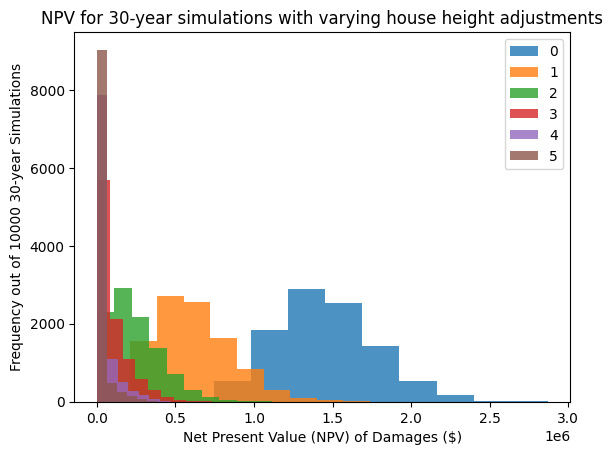

In [196]:
plt.hist(results_df[results_df['delta_h']==0]['NPV'], label = '0', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==1]['NPV'], label = '1', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==2]['NPV'], label = '2', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==3]['NPV'], label = '3', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==4]['NPV'], label = '4', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==5]['NPV'], label = '5', alpha = 0.8)
plt.legend()
plt.xlabel('Net Present Value (NPV) of Damages ($)')
plt.ylabel(f'Frequency out of {num_simulations} 30-year Simulations')
plt.title(f'NPV for 30-year simulations with varying house height adjustments')

Text(0.5, 1.0, 'Reduction in damage compared to baseline with varying house height adjustments')

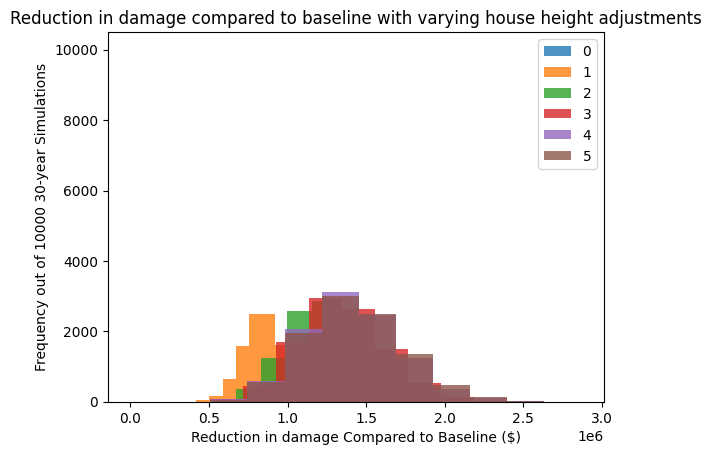

In [197]:
plt.hist(results_df[results_df['delta_h']==0]['damage_compared_baseline'], label = '0', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==1]['damage_compared_baseline'], label = '1', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==2]['damage_compared_baseline'], label = '2', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==3]['damage_compared_baseline'], label = '3', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==4]['damage_compared_baseline'], label = '4', alpha = 0.8)
plt.hist(results_df[results_df['delta_h']==5]['damage_compared_baseline'], label = '5', alpha = 0.8)
plt.legend()
plt.xlabel('Reduction in damage Compared to Baseline ($)')
plt.ylabel(f'Frequency out of {num_simulations} 30-year Simulations')
plt.title(f'Reduction in damage compared to baseline with varying house height adjustments')

^Trying to think through the cost benefit portion: if the net present value of DAMAGES is less than the cost of elevating, it's worth it??? or....

(array([1.0416e+04, 1.0449e+04, 1.3324e+04, 2.6645e+04, 2.8014e+04,
        1.5088e+04, 4.9500e+03, 9.5100e+02, 1.4300e+02, 2.0000e+01]),
 array([      0.        ,  276321.28923254,  552642.57846509,
         828963.86769763, 1105285.15693017, 1381606.44616271,
        1657927.73539526, 1934249.0246278 , 2210570.31386034,
        2486891.60309288, 2763212.89232543]),
 <BarContainer object of 10 artists>)

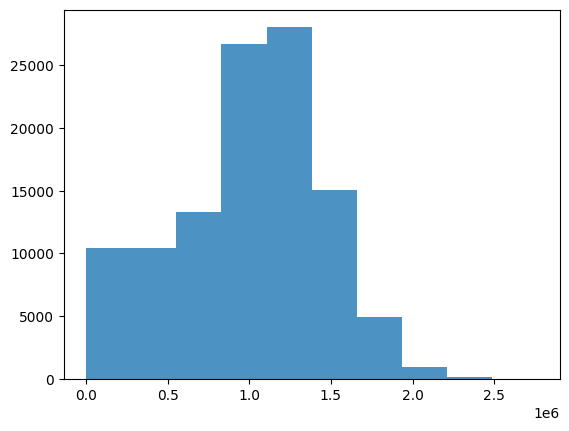

In [198]:
plt.hist(results_df['net'], alpha = 0.8)

In [199]:
# net present benefit (benefit - cost, which is damage no elevation - damage elevation - cost of elevation) per elevation
#group data based on delta_h, take average of "net" and "cost":



hat elevation heights pass the cost-benefit test? You
    can assume that the costs of elevation are all up front (that is, in
    year 0).
-   What height (including a possible elevation of 0m) maximizes the NPV
    of net benefits (benefits - ocsts)?[1]

In [209]:
average_values = results_df.groupby('delta_h', as_index=False)['net'].mean()
# average_values

Text(0.5, 1.0, 'Average net benefit of raising house to different levels')

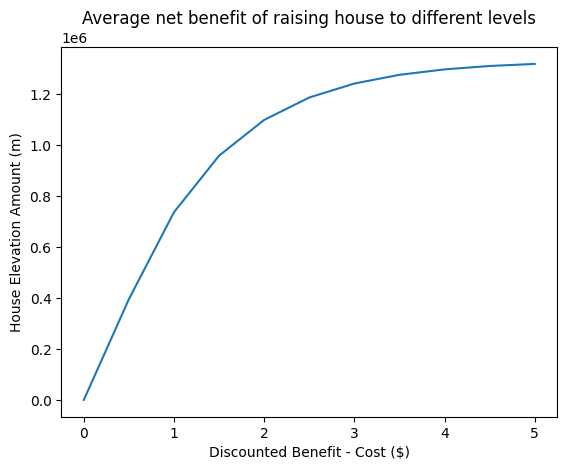

In [210]:
plt.plot(average_values['delta_h'], average_values['net'])
plt.xlabel('Discounted Benefit - Cost ($)')
plt.ylabel('House Elevation Amount (m)')
plt.title(f'Average net benefit of raising house to different levels')

In [ ]:
# calculating and plotting expected damage over simulations (e.g., for 0 height difference) to see MC convergence:
sim_averages = results_df.groupby(['delta_h', 'sim'], as_index=False)[['NPV', 'net']].mean() # and also running mean and standard deviation of each of these, e.g., NPV for a specific delta_h running average over simulations
sim_averages

,delta_h,sim,NPV,net
0,0.0,0,1.754009e+06,0.000000e+00
1,0.0,1,1.099420e+06,0.000000e+00
2,0.0,2,1.506585e+06,0.000000e+00
3,0.0,3,1.404899e+06,0.000000e+00
4,0.0,4,1.062059e+06,0.000000e+00
...,...,...,...,...
109995,5.0,9995,0.000000e+00,1.501463e+06
109996,5.0,9996,0.000000e+00,1.131003e+06
109997,5.0,9997,0.000000e+00,1.298972e+06
109998,5.0,9998,0.000000e+00,1.593981e+06


**USED CHATGPT (OpenAI, 2025):** For the code below - I was having trouble finding the right way to calculate a cumulative average and standard error for the mean and asked chatgpt to help, so that I could look at MC convergence (which we're not asked to do in the question but I was just curious about and didn't want to spend too long working on the code for).

In [215]:
df_sub = sim_averages[sim_averages['delta_h'] == 0].sort_values('sim')

# Compute running mean and standard deviation of NPV over simulations
df_sub['running_mean_NPV'] = df_sub['NPV'].expanding().mean()
df_sub['running_std_NPV'] = df_sub['NPV'].expanding().std()

# Compute running standard error (SEM)
df_sub['running_sem_NPV'] = df_sub['running_std_NPV'] / np.sqrt(df_sub.index + 1)  # sqrt of sample size


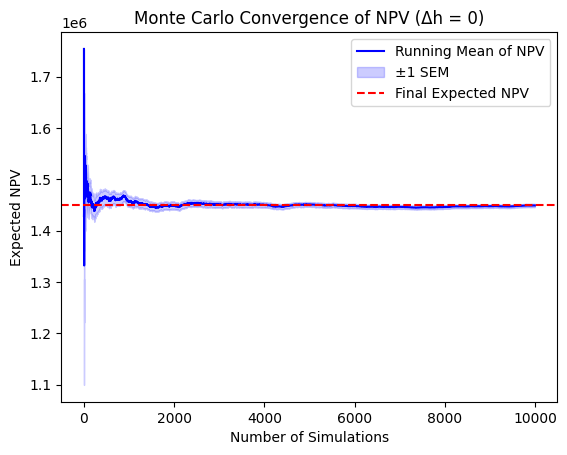

In [218]:
# Plot running mean
plt.plot(df_sub['sim'], df_sub['running_mean_NPV'], label='Running Mean of NPV', color='blue')

# Plot confidence intervals (±1 SEM)
plt.fill_between(df_sub['sim'], 
                 df_sub['running_mean_NPV'] - df_sub['running_sem_NPV'], 
                 df_sub['running_mean_NPV'] + df_sub['running_sem_NPV'], 
                 color='blue', alpha=0.2, label='±1 SEM')

# Horizontal line for final expected NPV
plt.axhline(y=df_sub['running_mean_NPV'].iloc[-1], color='red', linestyle='--', label='Final Expected NPV')

# Labels and title
plt.xlabel("Number of Simulations")
plt.ylabel("Expected NPV")
plt.legend()
plt.title(f"Monte Carlo Convergence of NPV (Δh = 0)")
plt.show()

## References

OpenAI. (2025). ChatGPT (March 12 version) [Large language model]. https://chatgpt.com/
